# LeetCode #228: Summary Ranges

https://leetcode.com/problems/summary-ranges/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n)$ | $O(n)$ |
| **Linear Scan** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Load all elements into a HashSet. For each element that has no predecessor in the set, scan forward using set lookups until the sequence breaks. Correct, but wastes $O(n)$ space on a set when the array is already sorted — the sorted order makes membership checks unnecessary.

### Optimal: Linear Scan ★
Use two indices: `start` anchors the beginning of the current range and `end` advances through the array. A range closes whenever the next element is not exactly `nums[end] + 1` (or `end` reaches the last element). Leverages the sorted-unique guarantee to detect gaps with a single subtraction — no hash lookups needed.

**Why this is better than Brute Force:** The sorted input makes the HashSet redundant. Comparing adjacent elements directly gives $O(1)$ gap detection per step, reducing auxiliary space from $O(n)$ to $O(1)$.

**Constraints:**
* 0 ≤ nums.length ≤ 20
* −2³¹ ≤ nums[i] ≤ 2³¹ − 1
* All values of nums are unique and sorted in ascending order

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<string> SummaryRanges(int[] nums) {
        var result = new List<string>();
        int start = 0;
        for (int end = 0; end < nums.Length; end++) {
            // Range closes when the sequence breaks or the array ends
            if (end == nums.Length - 1 || nums[end + 1] != nums[end] + 1) {
                result.Add(start == end ? $"{nums[start]}" : $"{nums[start]}->{nums[end]}");
                start = end + 1;
            }
        }
        return result;
    }
}

### Python

In [ ]:
class Solution:
    def summaryRanges(self, nums: List[int]) -> List[str]:
        result, start = [], 0
        for end in range(len(nums)):
            # Range closes when the sequence breaks or the array ends
            if end == len(nums) - 1 or nums[end + 1] != nums[end] + 1:
                result.append(str(nums[start]) if start == end
                               else f"{nums[start]}->{nums[end]}")
                start = end + 1
        return result

### Go

In [ ]:
import "fmt"

func summaryRanges(nums []int) []string {
    result := []string{}
    start := 0
    for end := 0; end < len(nums); end++ {
        // Range closes when the sequence breaks or the array ends
        if end == len(nums)-1 || nums[end+1] != nums[end]+1 {
            if start == end {
                result = append(result, fmt.Sprintf("%d", nums[start]))
            } else {
                result = append(result, fmt.Sprintf("%d->%d", nums[start], nums[end]))
            }
            start = end + 1
        }
    }
    return result
}

### Rust

In [ ]:
pub fn summary_ranges(nums: Vec<i32>) -> Vec<String> {
    let mut result = Vec::new();
    let mut start = 0usize;
    for end in 0..nums.len() {
        // Range closes when the sequence breaks or the array ends
        if end == nums.len() - 1 || nums[end + 1] != nums[end] + 1 {
            if start == end {
                result.push(nums[start].to_string());
            } else {
                result.push(format!("{}->{}", nums[start], nums[end]));
            }
            start = end + 1;
        }
    }
    result
}

## Example Scenarios

**1. Common Case**
**Input:** nums = [0, 1, 2, 4, 5, 7]
end=0: next=1=0+1, continue. end=1: next=2=1+1, continue. end=2: next=4≠3 → close range "0->2", start=3. end=3: next=5=4+1, continue. end=4: next=7≠6 → close "4->5", start=5. end=5: last element → close "7". Output: **["0->2", "4->5", "7"]**.

**2. Slightly Complex — alternating ranges and singletons**
**Input:** nums = [0, 2, 3, 4, 6, 8, 9]
end=0: next=2≠1 → "0" (singleton). end=1: next=3=2+1, continue. end=2: next=4=3+1, continue. end=3: next=6≠5 → "2->4". end=4: next=8≠7 → "6" (singleton). end=5: next=9=8+1, continue. end=6: last → "8->9". Output: **["0", "2->4", "6", "8->9"]**.

**3. Edge Case: Time Factor — fully consecutive array**
**Input:** nums = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
The `if` branch fires only once at end=9 (last element). All other iterations compare adjacent elements and continue. $n$ iterations, 1 string built, 0 intermediate strings allocated. A brute-force set-scan that builds partial ranges per-element would still be $O(n)$ but performs $n$ set lookups vs. $n$ integer comparisons — constants differ. Output: **["1->10"]**.

**4. Edge Case: Space Factor — all singletons**
**Input:** nums = [0, 2, 4, 6, 8]
Every element is isolated: nums[end+1] ≠ nums[end]+1 at every step. The `if` fires at every index. $n$ single-element strings are appended, each a singleton label. This is the worst case for output size: $O(n)$ strings. The algorithm itself uses $O(1)$ extra space (just `start` and `end`) — only the required output is $O(n)$. Output: **["0", "2", "4", "6", "8"]**.

**5. Almost-Impossible but Plausible — empty array**
**Input:** nums = []
The for loop body never executes (range 0..0 is empty). `result` is returned immediately as an empty list. No index out-of-bounds risk: the loop guard `end < nums.Length` (or equivalent) prevents any access. Output: **[]**.

## Infographic

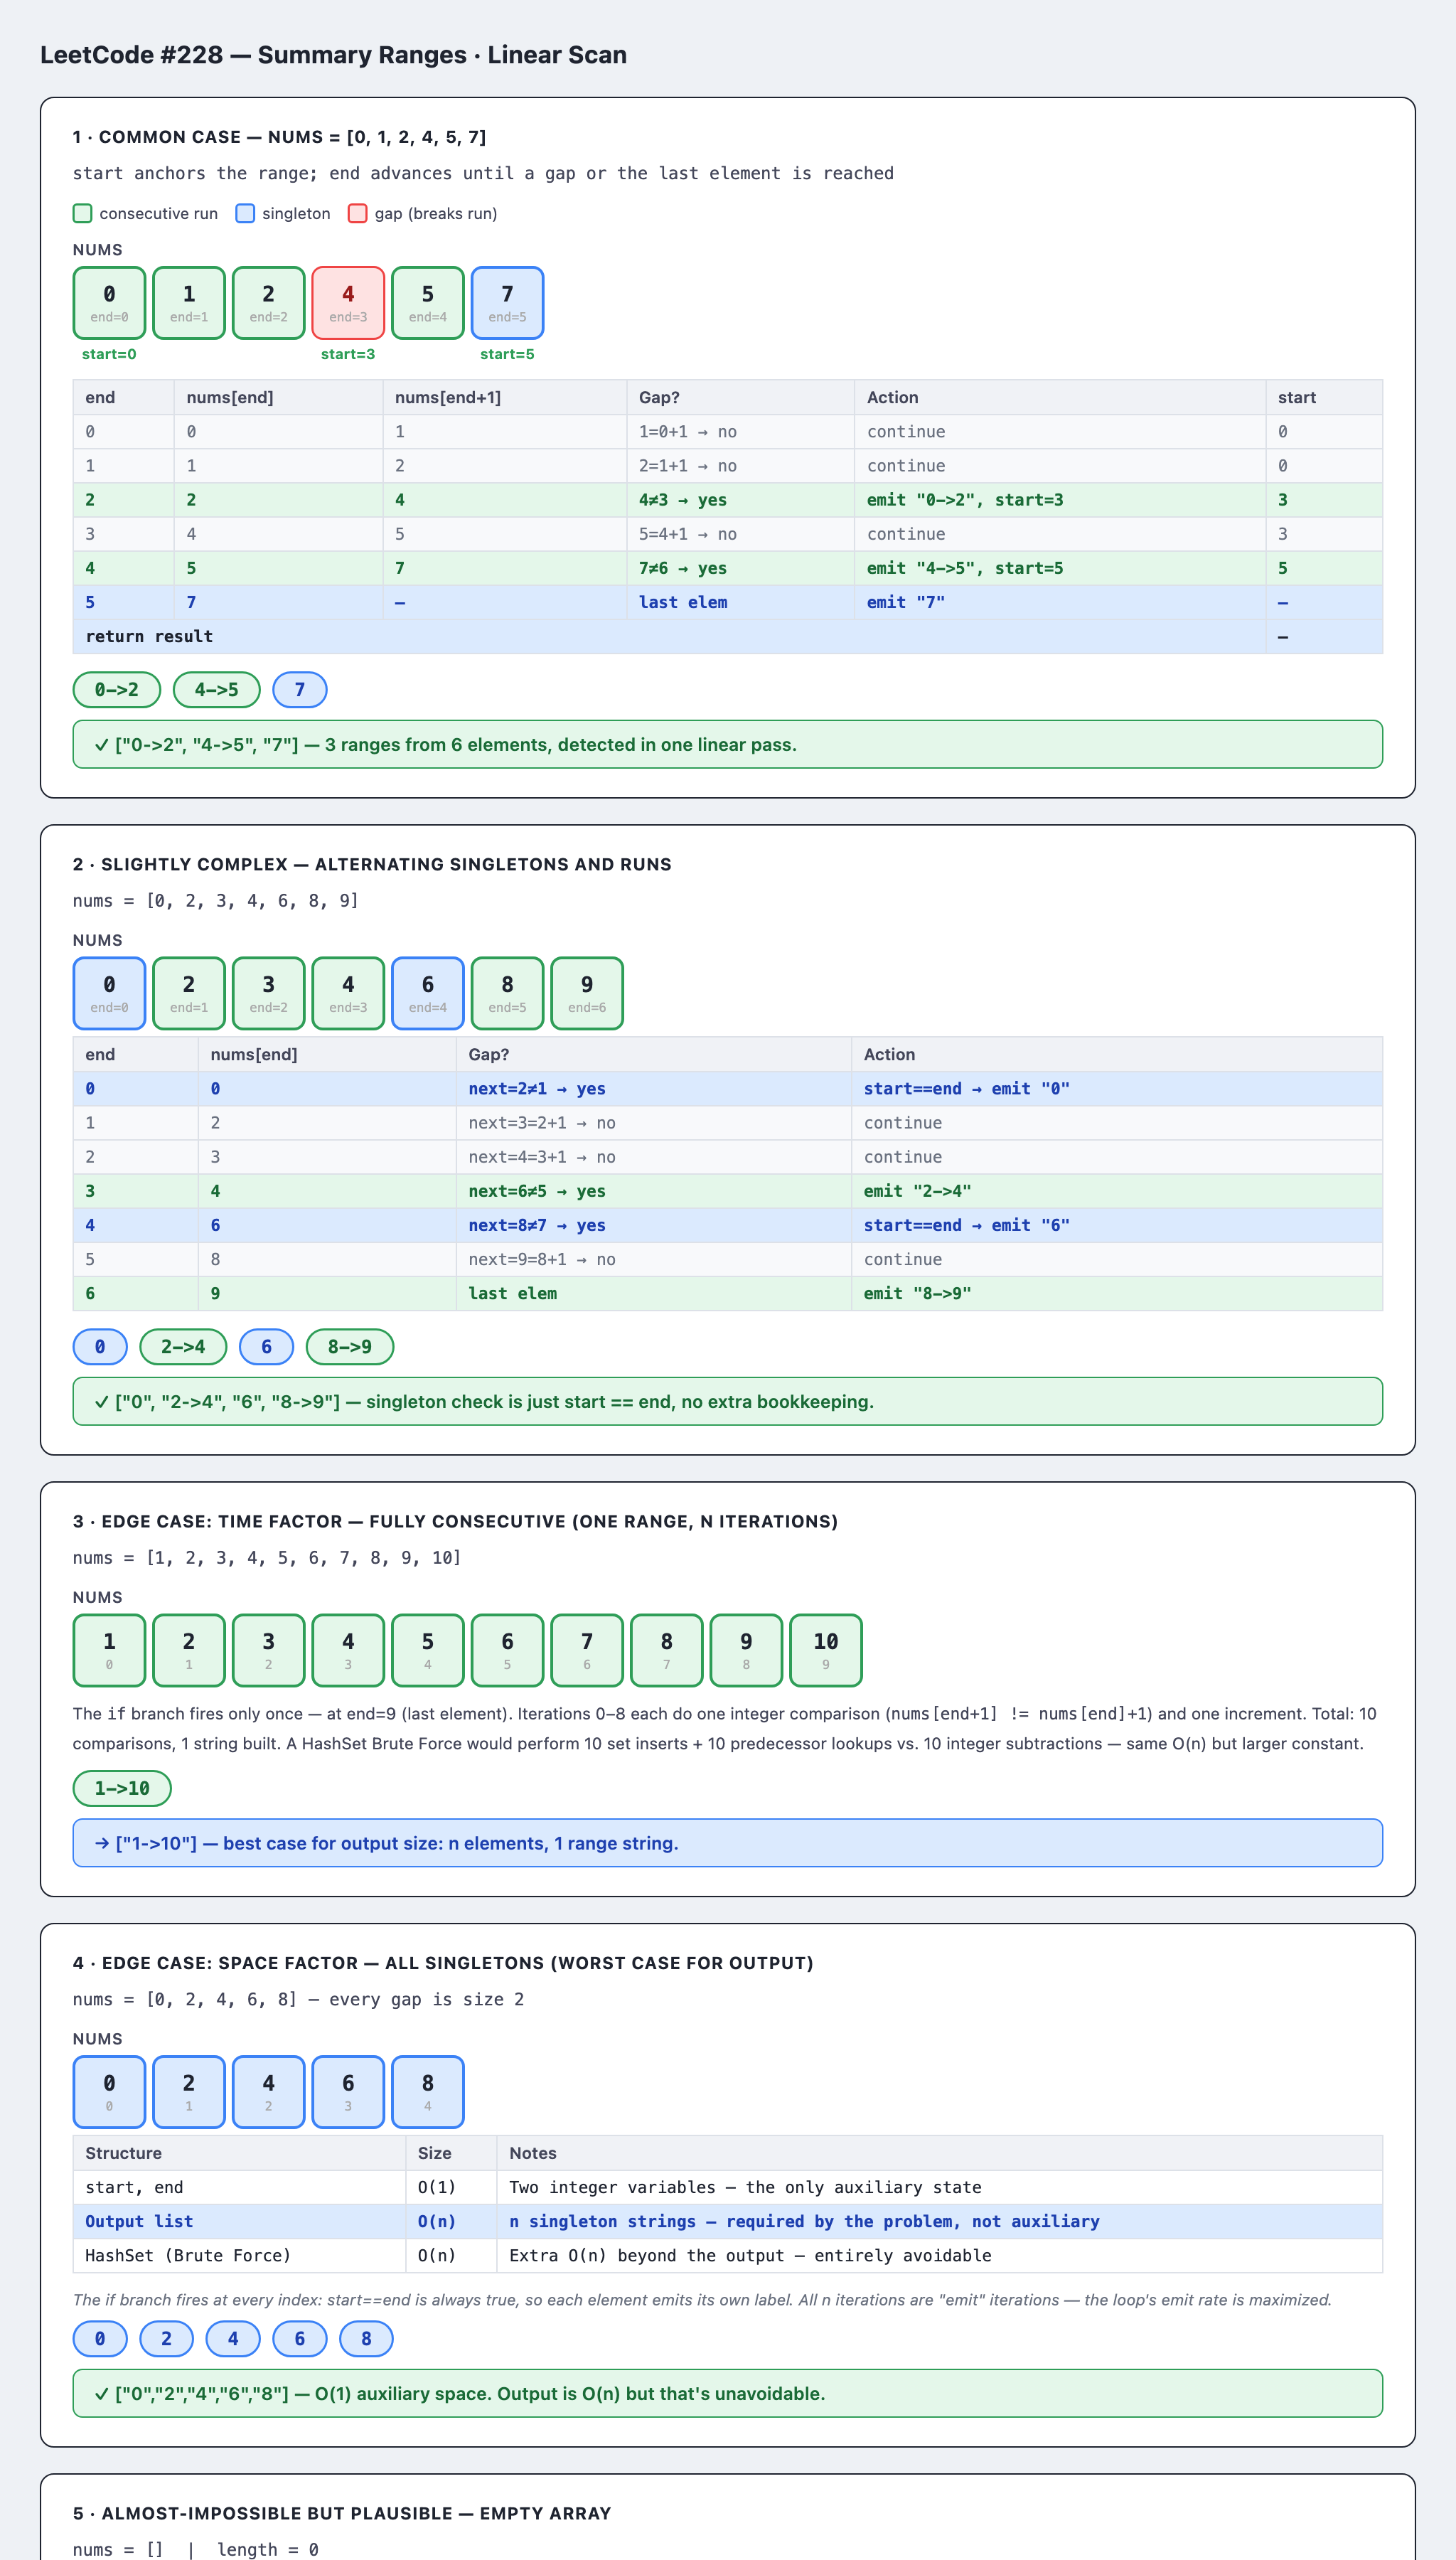